# 03 - Análisis de estacionalidad

En este cuaderno se analiza el comportamiento temporal de las ventas del Rossmann Store Sales Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
serie_ventas = pd.read_csv("../01_data/serie_ventas_preparada.csv")
serie_ventas["Date"] = pd.to_datetime(serie_ventas["Date"])

serie_ventas.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [3]:
resumen_serie = pd.DataFrame({
    "Fecha inicial": [serie_ventas["Date"].min()],
    "Fecha final": [serie_ventas["Date"].max()],
    "Total de días": [serie_ventas.shape[0]],
    "Venta promedio diaria": [serie_ventas["Sales"].mean()],
    "Venta mínima diaria": [serie_ventas["Sales"].min()],
    "Venta máxima diaria": [serie_ventas["Sales"].max()]
})

resumen_serie

,Fecha inicial,Fecha final,Total de días,Venta promedio diaria,Venta mínima diaria,Venta máxima diaria
0,2013-01-01,2015-07-31,942,"6,234,798.96",97235,15623548


## Visualización temporal general

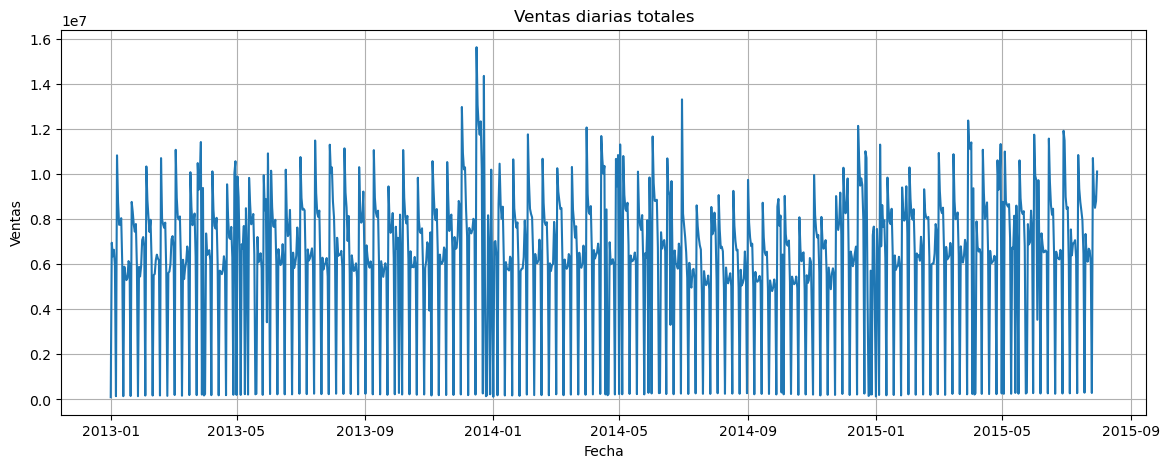

In [4]:
plt.figure(figsize=(14,5))
plt.plot(serie_ventas["Date"], serie_ventas["Sales"])
plt.title("Ventas diarias totales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

In [5]:
serie_ventas["Year"] = serie_ventas["Date"].dt.year
serie_ventas["Month"] = serie_ventas["Date"].dt.month
serie_ventas["DayOfWeek"] = serie_ventas["Date"].dt.dayofweek + 1
serie_ventas["WeekOfYear"] = serie_ventas["Date"].dt.isocalendar().week.astype(int)

serie_ventas.head()

,Date,Sales,Year,Month,DayOfWeek,WeekOfYear
0,2013-01-01,97235,2013,1,2,1
1,2013-01-02,6949829,2013,1,3,1
2,2013-01-03,6347820,2013,1,4,1
3,2013-01-04,6638954,2013,1,5,1
4,2013-01-05,5951593,2013,1,6,1


## Estacionalidad mensual

In [6]:
ventas_mes = serie_ventas.groupby("Month")["Sales"].mean().reset_index()

ventas_mes

,Month,Sales
0,1,"6,093,857.25"
1,2,"6,294,457.26"
2,3,"6,449,805.44"
3,4,"6,398,836.61"
4,5,"6,120,948.57"
5,6,"6,423,475.28"
6,7,"6,398,486.08"
7,8,"5,835,341.97"
8,9,"5,709,502.18"
9,10,"5,675,463.35"


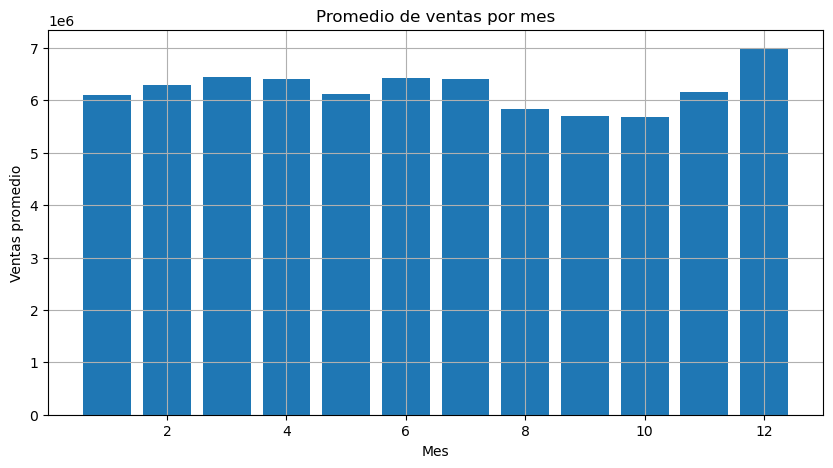

In [7]:
plt.figure(figsize=(10,5))
plt.bar(ventas_mes["Month"], ventas_mes["Sales"])
plt.title("Promedio de ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas promedio")
plt.grid(True)
plt.show()

## Estacionalidad por día de la semana

In [8]:
ventas_dia_semana = serie_ventas.groupby("DayOfWeek")["Sales"].mean().reset_index()

ventas_dia_semana

,DayOfWeek,Sales
0,1,"8,434,350.84"
1,2,"7,558,606.89"
2,3,"7,073,798.99"
3,4,"6,749,464.51"
4,5,"7,263,377.34"
5,6,"6,315,803.99"
6,7,"220,533.08"


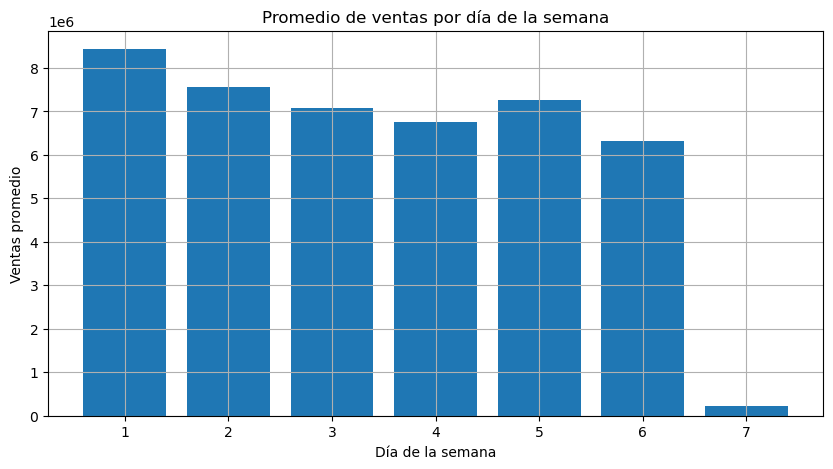

In [9]:
plt.figure(figsize=(10,5))
plt.bar(ventas_dia_semana["DayOfWeek"], ventas_dia_semana["Sales"])
plt.title("Promedio de ventas por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Ventas promedio")
plt.grid(True)
plt.show()

## Estacionalidad anual

In [ ]:
ventas_anio = serie_ventas.groupby("Year")["Sales"].mean().reset_index()

ventas_anio

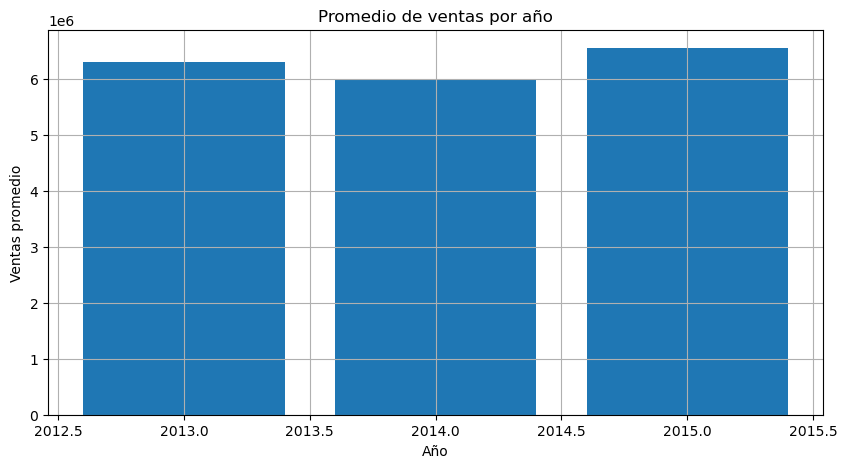

In [11]:
plt.figure(figsize=(10,5))
plt.bar(ventas_anio["Year"], ventas_anio["Sales"])
plt.title("Promedio de ventas por año")
plt.xlabel("Año")
plt.ylabel("Ventas promedio")
plt.grid(True)
plt.show()

## Tendencia mensual

In [12]:
ventas_mensuales = serie_ventas.set_index("Date")["Sales"].resample("M").sum().reset_index()

ventas_mensuales.head()

,Date,Sales
0,2013-01-31,180132207
1,2013-02-28,171534275
2,2013-03-31,201180369
3,2013-04-30,183431432
4,2013-05-31,185411063


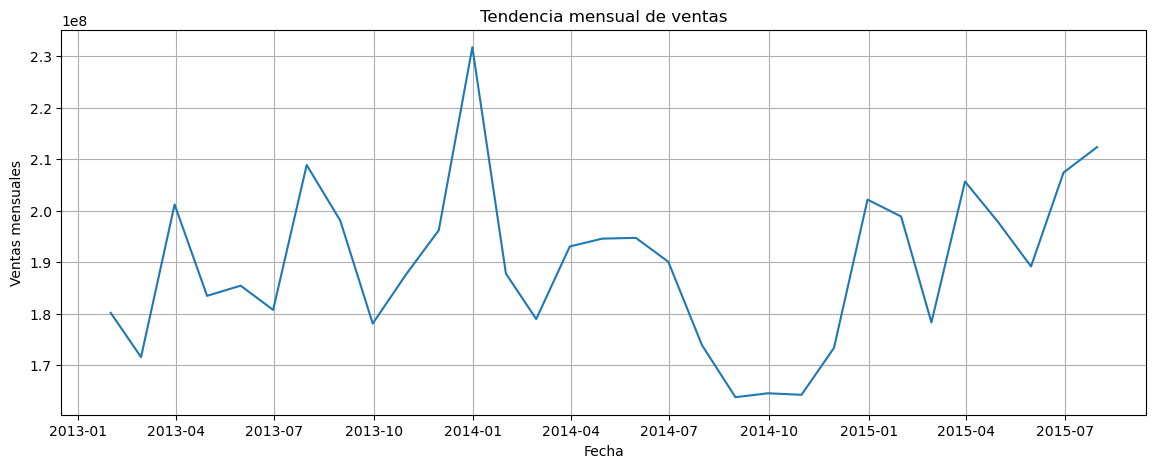

In [13]:
plt.figure(figsize=(14,5))
plt.plot(ventas_mensuales["Date"], ventas_mensuales["Sales"])
plt.title("Tendencia mensual de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas mensuales")
plt.grid(True)
plt.show()

## Media móvil

In [14]:
serie_ventas["Media_movil_7"] = serie_ventas["Sales"].rolling(window=7).mean()
serie_ventas["Media_movil_30"] = serie_ventas["Sales"].rolling(window=30).mean()

serie_ventas.head()

,Date,Sales,Year,Month,DayOfWeek,WeekOfYear,Media_movil_7,Media_movil_30
0,2013-01-01,97235,2013,1,2,1,NaN,NaN
1,2013-01-02,6949829,2013,1,3,1,NaN,NaN
2,2013-01-03,6347820,2013,1,4,1,NaN,NaN
3,2013-01-04,6638954,2013,1,5,1,NaN,NaN
4,2013-01-05,5951593,2013,1,6,1,NaN,NaN


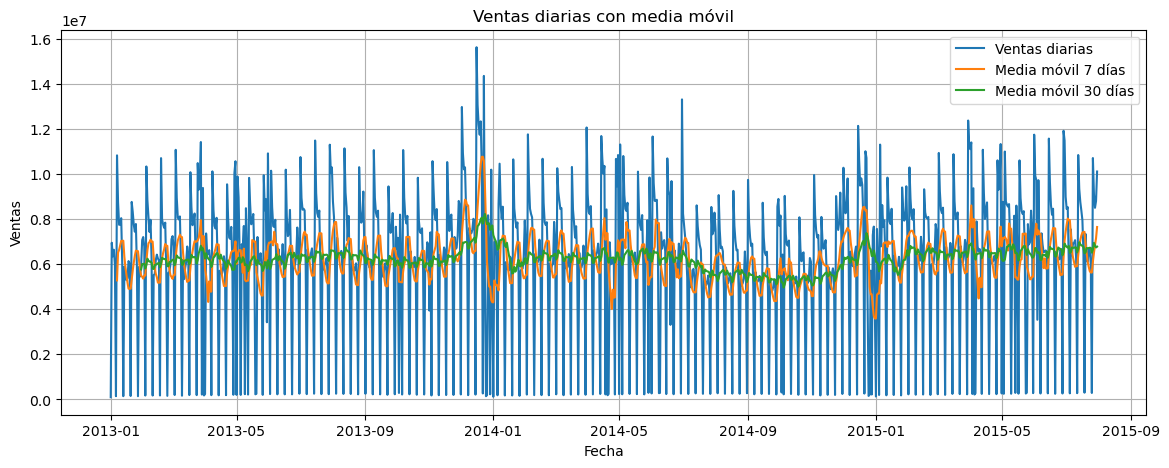

In [15]:
plt.figure(figsize=(14,5))
plt.plot(serie_ventas["Date"], serie_ventas["Sales"], label="Ventas diarias")
plt.plot(serie_ventas["Date"], serie_ventas["Media_movil_7"], label="Media móvil 7 días")
plt.plot(serie_ventas["Date"], serie_ventas["Media_movil_30"], label="Media móvil 30 días")
plt.title("Ventas diarias con media móvil")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
serie_ventas.to_csv("../01_data/serie_ventas_estacionalidad.csv", index=False)

## Conclusión

El análisis permitió observar el comportamiento temporal de las ventas diarias, así como patrones por mes, día de la semana y año.

También se construyeron visualizaciones temporales y medias móviles para identificar tendencia y variaciones en la demanda. Esta fase cumple con el análisis de estacionalidad solicitado en el taller.